In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv(
    "/content/household_power_consumption.txt",
    sep=";",
    na_values="?"
)

In [ ]:
df.sample(15)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
101103,24/2/2007,22:27:00,0.212,0.000,237.79,0.8,0.0,0.0,0.0
19301,30/12/2006,03:05:00,0.412,0.310,246.90,2.0,0.0,1.0,0.0
34655,9/1/2007,18:59:00,2.324,0.000,237.65,9.8,0.0,0.0,17.0
54299,23/1/2007,10:23:00,0.374,0.222,240.73,1.8,0.0,0.0,0.0
88585,16/2/2007,05:49:00,0.624,0.000,240.55,2.8,0.0,0.0,0.0
48943,19/1/2007,17:07:00,1.358,0.110,240.86,5.6,0.0,0.0,18.0
44953,16/1/2007,22:37:00,2.464,0.000,243.87,10.4,0.0,0.0,0.0
40307,13/1/2007,17:11:00,3.174,0.144,236.71,13.4,0.0,0.0,17.0
33624,9/1/2007,01:48:00,0.360,0.222,241.23,1.8,0.0,1.0,0.0
14779,26/12/2006,23:43:00,0.420,0.000,246.35,2.0,0.0,0.0,0.0


In [ ]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [ ]:
df.shape

(113606, 9)

In [ ]:
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,8
Global_reactive_power,8
Voltage,8
Global_intensity,8
Sub_metering_1,8
Sub_metering_2,8
Sub_metering_3,8


In [ ]:
df.dtypes

,0
Date,object
Time,object
Global_active_power,float64
Global_reactive_power,float64
Voltage,float64
Global_intensity,float64
Sub_metering_1,float64
Sub_metering_2,float64
Sub_metering_3,float64


In [ ]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [ ]:
df = df.sort_values('Datetime')
df = df.reset_index(drop=True)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [ ]:
df = df.drop(['Date', 'Time'], axis=1)

In [ ]:
df.head()
df.shape

(113606, 8)

In [ ]:
df.isnull().sum()

,0
Global_active_power,8
Global_reactive_power,8
Voltage,8
Global_intensity,8
Sub_metering_1,8
Sub_metering_2,8
Sub_metering_3,8
Datetime,0


In [ ]:
#EDA

In [ ]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
count,113598.000000,113598.000000,113598.000000,113598.000000,113598.000000,113598.000000,113598.000000,113606
mean,1.516988,0.123252,240.865772,6.412845,1.179748,1.808843,6.940738,2007-01-25 04:06:29.999999488
min,0.194000,0.000000,223.490000,0.800000,0.000000,0.000000,0.000000,2006-12-16 17:24:00
25%,0.332000,0.000000,238.710000,1.400000,0.000000,0.000000,0.000000,2007-01-05 10:45:15
50%,1.340000,0.112000,241.090000,5.600000,0.000000,0.000000,0.000000,2007-01-25 04:06:30
75%,2.342000,0.190000,243.200000,9.800000,0.000000,1.000000,17.000000,2007-02-13 21:27:45
max,10.670000,0.874000,251.700000,46.400000,77.000000,78.000000,20.000000,2007-03-05 14:49:00
std,1.340256,0.115204,3.356432,5.655724,6.347081,7.444492,8.566840,NaN


In [ ]:
df['Global_active_power'].describe()

,Global_active_power
count,113598.000000
mean,1.516988
std,1.340256
min,0.194000
25%,0.332000
50%,1.340000
75%,2.342000
max,10.670000


In [ ]:
#highest consumption periods
df.nlargest(10, 'Global_active_power')[
    ['Datetime', 'Global_active_power']
]

,Datetime,Global_active_power
112450,2007-03-04 19:34:00,10.670
112449,2007-03-04 19:33:00,10.650
112448,2007-03-04 19:32:00,10.154
112451,2007-03-04 19:35:00,9.922
113149,2007-03-05 07:13:00,9.486
98151,2007-02-22 21:15:00,9.410
98145,2007-02-22 21:09:00,9.392
98144,2007-02-22 21:08:00,9.374
98150,2007-02-22 21:14:00,9.338
98143,2007-02-22 21:07:00,9.316


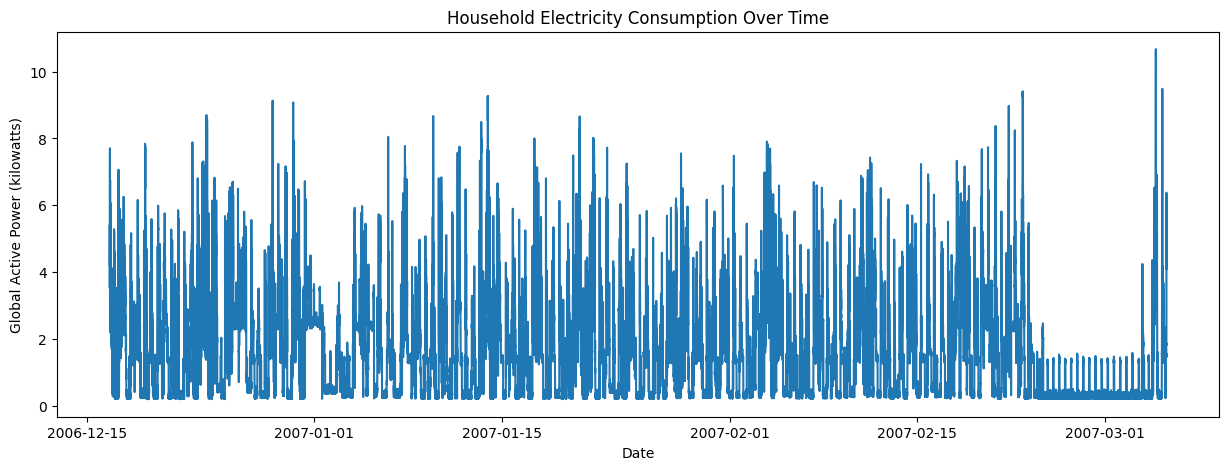

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    df['Datetime'],
    df['Global_active_power']
)

plt.xlabel('Date')
plt.ylabel('Global Active Power (kilowatts)')
plt.title('Household Electricity Consumption Over Time')

plt.show()

In [ ]:
df = df.set_index('Datetime')

# Calculate daily average active power
daily_power = df['Global_active_power'].resample('D').mean()

daily_power.head()

,Global_active_power
Datetime,
2006-12-16,3.053475
2006-12-17,2.354486
2006-12-18,1.530435
2006-12-19,1.157079
2006-12-20,1.545658


In [ ]:
daily_power.describe()

,Global_active_power
count,80.000000
mean,1.529434
std,0.658887
min,0.348431
25%,1.138201
50%,1.447087
75%,1.967999
max,3.314851


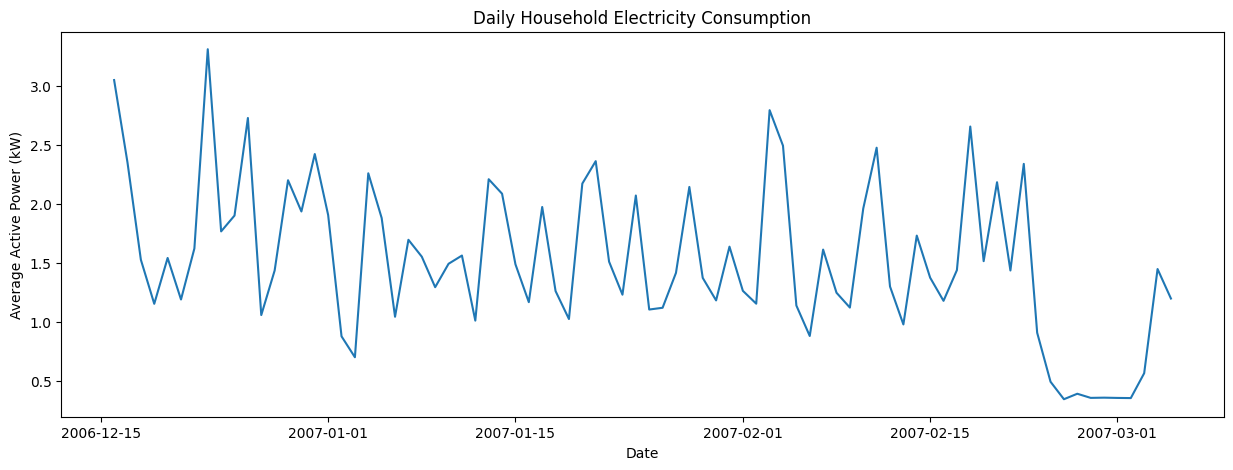

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(daily_power.index, daily_power)

plt.xlabel('Date')
plt.ylabel('Average Active Power (kW)')
plt.title('Daily Household Electricity Consumption')

plt.show()

In [ ]:
#daily energy consumption
daily_energy = df['Global_active_power'].resample('D').mean() * 24

daily_energy = daily_energy.dropna()

daily_energy.head()

,Global_active_power
Datetime,
2006-12-16,73.283394
2006-12-17,56.507667
2006-12-18,36.730433
2006-12-19,27.769900
2006-12-20,37.095800


In [ ]:
daily_energy.describe()

,Global_active_power
count,80.000000
mean,36.706415
std,15.813287
min,8.362333
25%,27.316825
50%,34.730100
75%,47.231967
max,79.556433


In [ ]:
#high consumption days
Q1 = daily_energy.quantile(0.25)
Q3 = daily_energy.quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

anomalies = daily_energy[daily_energy > upper_limit]

print("Upper limit:", upper_limit)
print("Number of unusual days:", len(anomalies))

Upper limit: 77.10467916666666
Number of unusual days: 1


In [ ]:
anomalies.sort_values(ascending=False).head(10)

,Global_active_power
Datetime,
2006-12-23,79.556433


In [ ]:
monthly_energy = daily_energy.resample('ME').sum()

monthly_energy.head()

,Global_active_power
Datetime,
2006-12-31,750.122943
2007-01-31,1150.268328
2007-02-28,941.559539
2007-03-31,94.562394


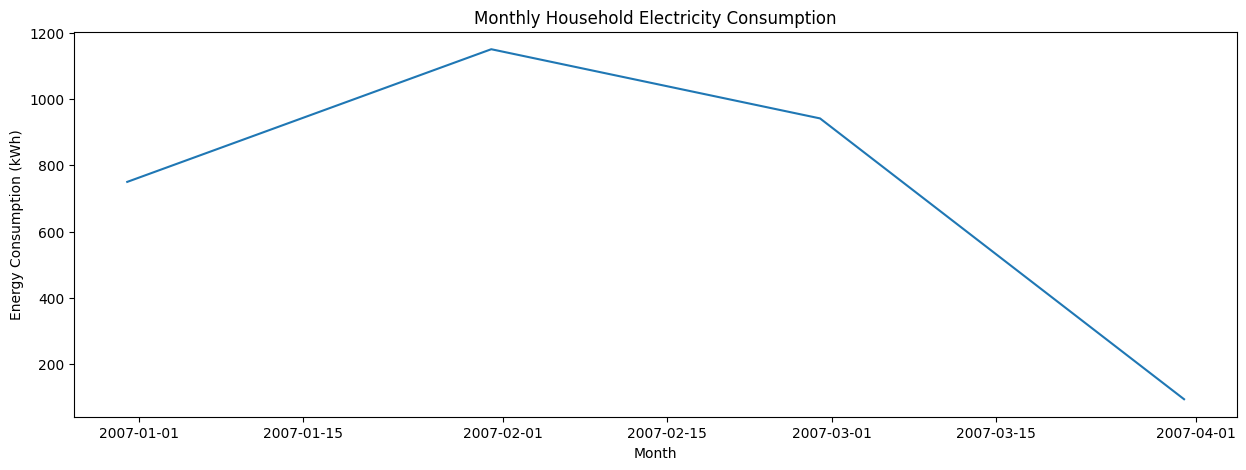

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(monthly_energy.index, monthly_energy)

plt.xlabel("Month")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Monthly Household Electricity Consumption")

plt.show()

In [ ]:
#Prediction Model
model_df = daily_energy.to_frame(name='energy')

model_df['day_of_week'] = model_df.index.dayofweek
model_df['month'] = model_df.index.month
model_df['day'] = model_df.index.day
model_df['lag_1'] = model_df['energy'].shift(1)
model_df['lag_7'] = model_df['energy'].shift(7)
model_df['rolling_7'] = model_df['energy'].shift(1).rolling(7).mean()

model_df = model_df.dropna()

model_df.head()

,energy,day_of_week,month,day,lag_1,lag_7,rolling_7
Datetime,,,,,,,
2006-12-23,79.556433,5,12,23,39.022300,73.283394,42.722812
2006-12-24,42.500200,6,12,24,79.556433,56.507667,43.618961
2006-12-25,45.718667,0,12,25,42.500200,36.730433,41.617894
2006-12-26,65.568500,1,12,26,45.718667,27.769900,42.901927
2006-12-27,25.479333,2,12,27,65.568500,37.095800,48.301727


In [ ]:
from sklearn.model_selection import train_test_split

features = [
    'day_of_week',
    'month',
    'day',
    'lag_1',
    'lag_7',
    'rolling_7'
]

X = model_df[features]
y = model_df['energy']

split = int(len(model_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 24.600665597913753
RMSE: 27.92202322245602


In [ ]:
baseline_predictions = X_test['lag_1']

baseline_mae = mean_absolute_error(y_test, baseline_predictions)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 11.019041128665663


In [ ]:
print("Random Forest MAE:", mae)

Random Forest MAE: 24.600665597913753


In [ ]:
model_df['rolling_3'] = model_df['energy'].shift(1).rolling(3).mean()
model_df['rolling_14'] = model_df['energy'].shift(1).rolling(14).mean()

model_df = model_df.dropna()

In [ ]:
features = [
    'day_of_week',
    'month',
    'day',
    'lag_1',
    'lag_7',
    'rolling_3',
    'rolling_7',
    'rolling_14'
]

X = model_df[features]
y = model_df['energy']

split = int(len(model_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Improved MAE:", mae)
print("Improved RMSE:", rmse)

Improved MAE: 28.52601085530613
Improved RMSE: 30.71928902793403


In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

day_of_week    0.436197
lag_7          0.157186
rolling_14     0.148171
lag_1          0.088314
rolling_7      0.054642
day            0.053778
rolling_3      0.046382
month          0.015330
dtype: float64


In [ ]:
baseline_predictions = X_test['lag_1'].values

print("Actual:", len(y_test))
print("Baseline:", len(baseline_predictions))

Actual: 12
Baseline: 12


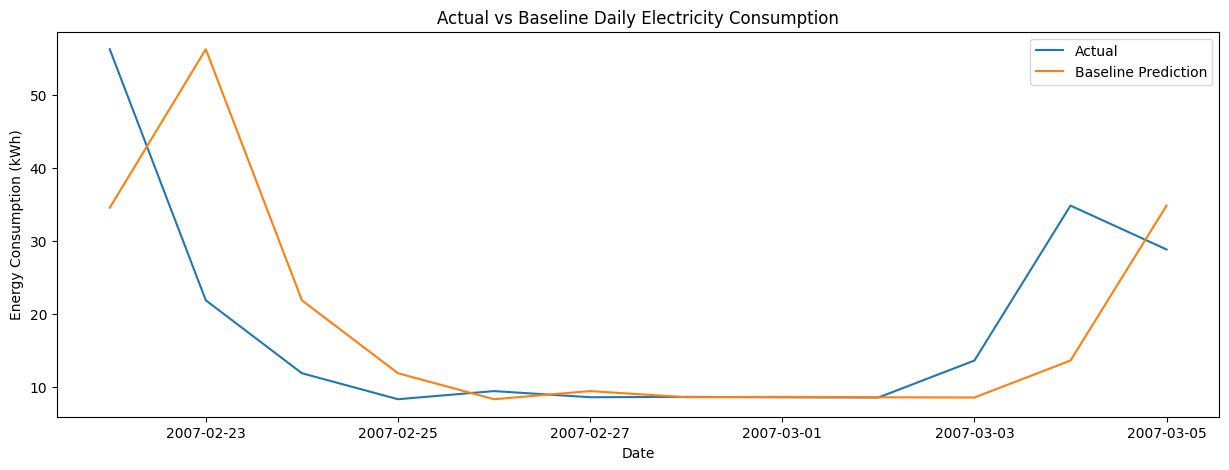

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(y_test.index, y_test, label='Actual')
plt.plot(
    y_test.index,
    baseline_predictions,
    label='Baseline Prediction'
)

plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Actual vs Baseline Daily Electricity Consumption")

plt.legend()
plt.show()

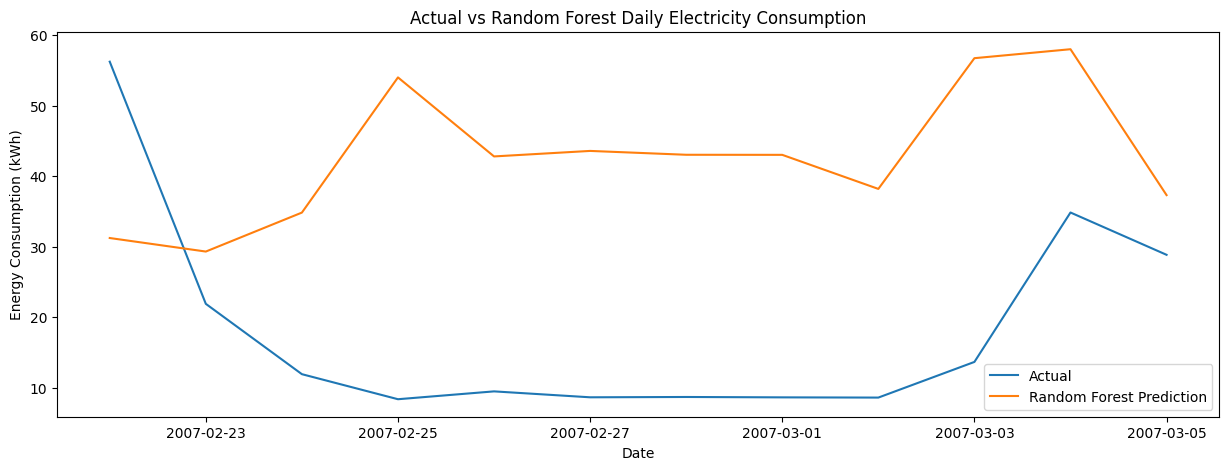

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(y_test.index, y_test.values, label='Actual')
plt.plot(y_test.index, predictions, label='Random Forest Prediction')

plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Actual vs Random Forest Daily Electricity Consumption")

plt.legend()
plt.show()

In [ ]:
# Basic insights from the dataset

print("Average daily consumption:", round(daily_energy.mean(), 2), "kWh")
print("Maximum daily consumption:", round(daily_energy.max(), 2), "kWh")
print("Minimum daily consumption:", round(daily_energy.min(), 2), "kWh")
print("Unusual days detected:", len(anomalies))

if len(anomalies) > 0:
    print("\nUnusual consumption days:")
    print(anomalies)

Average daily consumption: 36.71 kWh
Maximum daily consumption: 79.56 kWh
Minimum daily consumption: 8.36 kWh
Unusual days detected: 1

Unusual consumption days:
Datetime
2006-12-23    79.556433
Freq: D, Name: Global_active_power, dtype: float64


In [ ]:
average_usage = daily_energy.mean()
latest_usage = daily_energy.iloc[-1]

print("Average daily usage:", round(average_usage, 2), "kWh")
print("Latest available daily usage:", round(latest_usage, 2), "kWh")

if latest_usage > average_usage * 1.2:
    print("\nRecommendation:")
    print("Your recent electricity consumption is significantly above the historical average.")
    print("Check high-consumption appliances such as air conditioners, heaters, refrigerators, and washing machines.")
elif latest_usage < average_usage * 0.8:
    print("\nRecommendation:")
    print("Your recent electricity consumption is below the historical average.")
    print("Continue monitoring usage patterns to identify energy-saving practices.")
else:
    print("\nRecommendation:")
    print("Your recent electricity consumption is within the normal historical range.")

Average daily usage: 36.71 kWh
Latest available daily usage: 28.84 kWh

Recommendation:
Your recent electricity consumption is below the historical average.
Continue monitoring usage patterns to identify energy-saving practices.


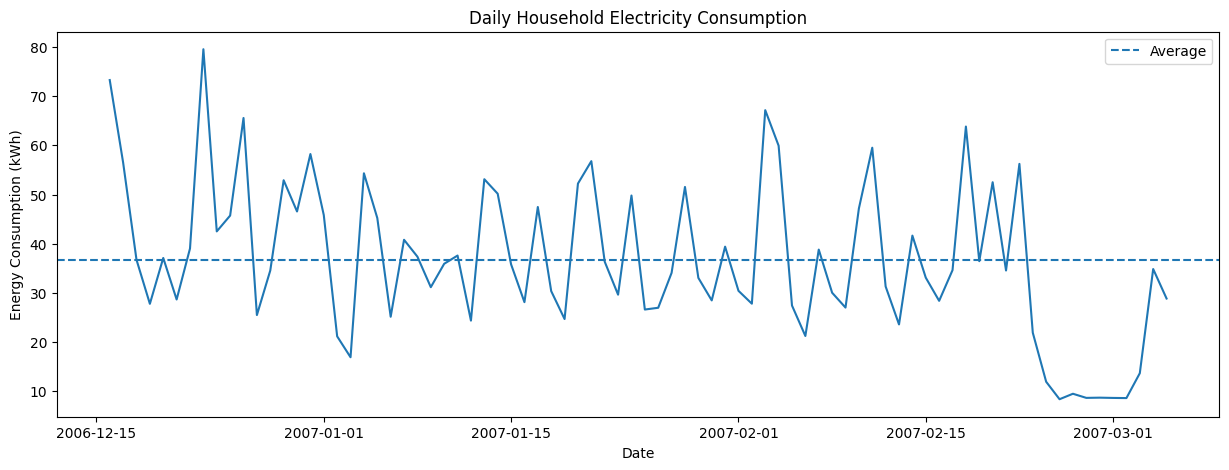

In [ ]:
#Daily Consumption Trend
plt.figure(figsize=(15,5))
plt.plot(daily_energy.index, daily_energy.values)
plt.axhline(daily_energy.mean(), linestyle='--', label='Average')
plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Daily Household Electricity Consumption")
plt.legend()
plt.show()

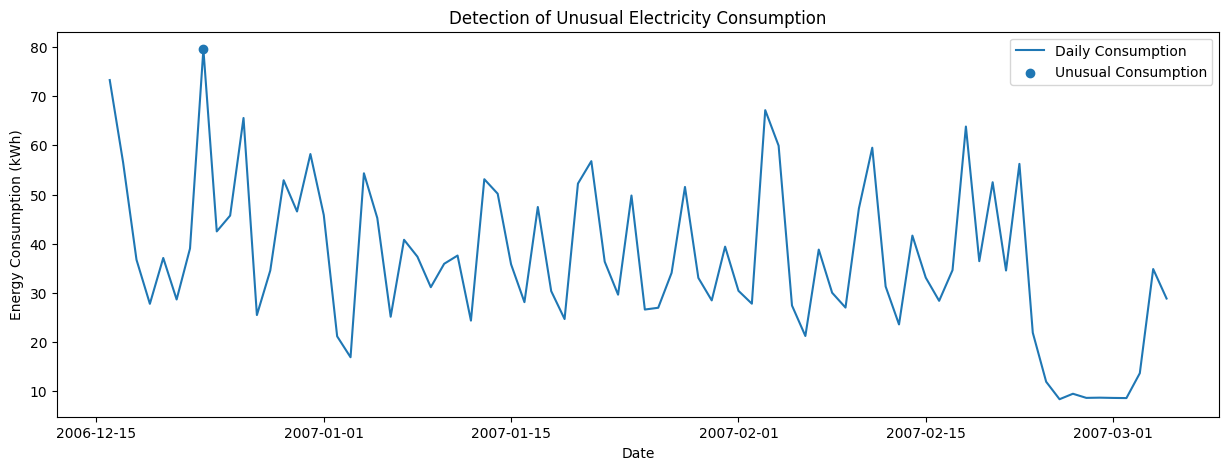

In [ ]:
#anomaly
plt.figure(figsize=(15,5))
plt.plot(daily_energy.index, daily_energy.values, label='Daily Consumption')

plt.scatter(
    anomalies.index,
    anomalies.values,
    label='Unusual Consumption'
)

plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Detection of Unusual Electricity Consumption")
plt.legend()
plt.show()

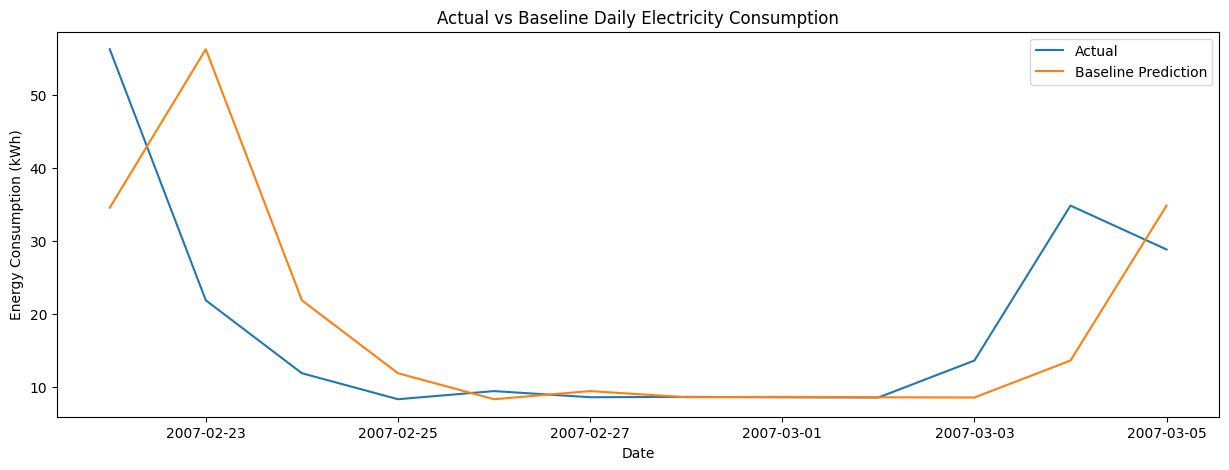

In [ ]:
#Actual Vs prediction
plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test.values, label='Actual')
plt.plot(y_test.index, baseline_predictions, label='Baseline Prediction')

plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Actual vs Baseline Daily Electricity Consumption")
plt.legend()
plt.show()